In [140]:
# Target:
# Predict: views OR likes
# Input features:
# publish_time
# category
# title length
# tags count
# comments

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [142]:
df = pd.read_csv(r"C:\Users\malik\Desktop\ML_Revise\06_poly_ridge_lasso\USvideos.csv")  # from Kaggle dataset
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


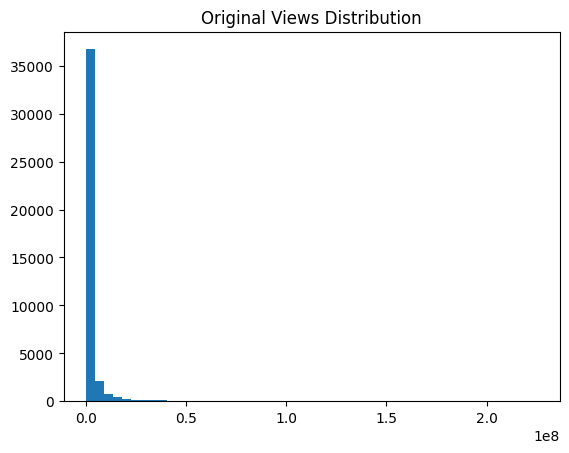

In [143]:
plt.hist(df['views'], bins=50)
plt.title("Original Views Distribution")
plt.show()

In [144]:
# Remove extreme outliers (top 1%)
df = df[df['views'] < df['views'].quantile(0.98)]

In [145]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

df['hour'] = df['publish_time'].dt.hour
df['day'] = df['publish_time'].dt.dayofweek
df['month'] = df['publish_time'].dt.month

df['title_length'] = df['title'].astype(str).apply(len)
df['tags_count'] = df['tags'].astype(str).apply(lambda x: len(x.split('|')))

# Log transform features (VERY IMPORTANT 🔥)
df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comment_count'])

In [146]:
y = np.log1p(df['views'])


In [147]:
features = [
    'hour', 'day', 'month',
    'title',   # text feature
    'title_length', 'tags_count',
    'category_id',
    'log_likes', 'log_comments'
]

X = df[features]


In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [149]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

num_features = ['hour', 'day', 'month', 'title_length', 'tags_count', 'log_likes', 'log_comments']
cat_features = ['category_id']
text_feature = 'title'

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('text', TfidfVectorizer(max_features=100), text_feature)
])

In [150]:
ridge_pipeline = Pipeline([
    ('preprocessing', preprocessor),

    ('model', Ridge())
])

param_grid_ridge = {
    'model__alpha': [0.1, 1, 10]
}

ridge_grid = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=3, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

In [151]:
lasso_pipeline = Pipeline([
    ('preprocessing', preprocessor),

    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {
 
    'model__alpha': [0.001, 0.01, 0.1]
}

lasso_grid = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=3, n_jobs=-1)
lasso_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

In [152]:
elastic_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('poly', PolynomialFeatures(degree=2,include_bias=False)),
    ('model', ElasticNet(max_iter=20000))
])

param_grid_elastic = {

    'model__alpha': [0.01, 0.1, 1,5],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

elastic_grid =  GridSearchCV(
    elastic_pipeline,
    param_grid_elastic,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

elastic_grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=20000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...], 'model__l1_ratio': [0.2, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [155]:
def evaluate(model, X_test, y_test, name):
    y_pred_log = model.predict(X_test)

    # LOG SCALE
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2_log = r2_score(y_test, y_pred_log)

    # ORIGINAL SCALE
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse_original = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name}")
    print("RMSE (log):", rmse_log)
    print("R2 (log):", r2_log)
    print("RMSE (original):", rmse_original)

    return y_true, y_pred, y_pred_log   # 

   

In [156]:
y_true_r, y_pred_r, y_pred_log_r = evaluate(ridge_grid, X_test, y_test, "Ridge")
y_true_l, y_pred_l, y_pred_log_l = evaluate(lasso_grid, X_test, y_test, "Lasso")
y_true_e, y_pred_e, y_pred_log_e = evaluate(elastic_grid, X_test, y_test, "ElasticNet")


Ridge
RMSE (log): 0.7639685544669291
R2 (log): 0.7833649331014034
RMSE (original): 1699674.045810012

Lasso
RMSE (log): 0.7684166832270591
R2 (log): 0.7808349180706328
RMSE (original): 1704542.6865609237

ElasticNet
RMSE (log): 0.6781336986989517
R2 (log): 0.8293098561632207
RMSE (original): 1802654.7445370434


np.float64(230995.70109593833)

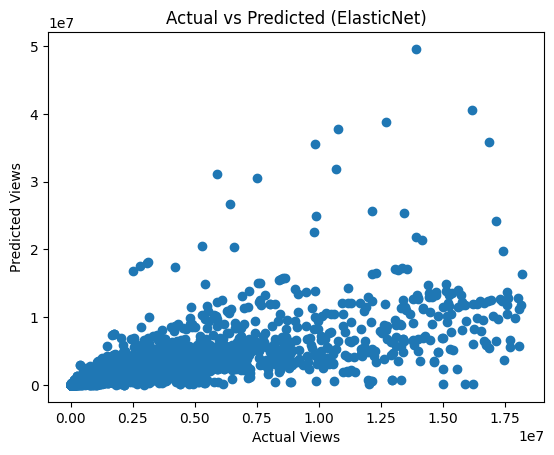

In [157]:
plt.scatter(y_true_e, y_pred_e)
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")
plt.title("Actual vs Predicted (ElasticNet)")
plt.show()

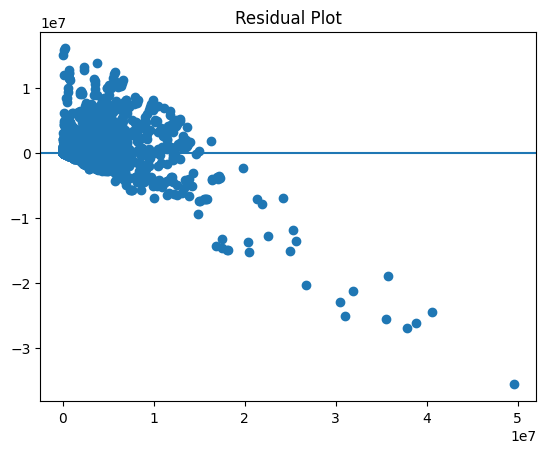

In [158]:
residuals = y_true_e - y_pred_e

plt.scatter(y_pred_e, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

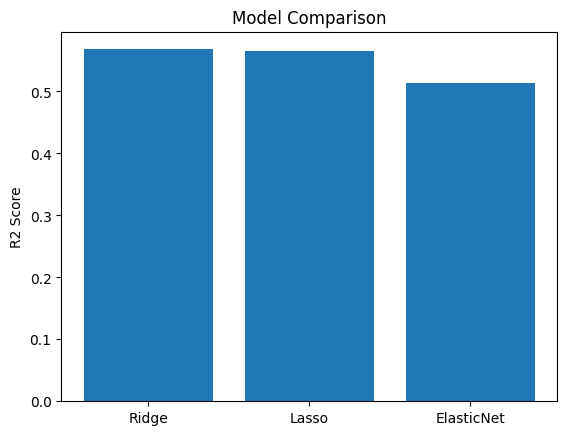

In [159]:
scores = [
    r2_score(y_true_r, y_pred_r),
    r2_score(y_true_l, y_pred_l),
    r2_score(y_true_e, y_pred_e)
]

models = ['Ridge', 'Lasso', 'ElasticNet']

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()

In [160]:
def predict_video(model, input_data):
    df_input = pd.DataFrame([input_data])
    pred_log = model.predict(df_input)
    return np.expm1(pred_log)[0]

In [175]:
# sample = {
#     'hour': 18,
#     'day': 5,
#     'month': 3,
#     'title': "Amazing cricket match highlights",
#     'title_length': 40,
#     'tags_count': 10,
#     'category_id': 24,
#     'log_likes': np.log1p(10000),
#     'log_comments': np.log1p(500)
# }

import numpy as np

sample = {
    'hour': 17,
    'day': 0,
    'month': 11,
    'title': "WE WANT TO TALK ABOUT OUR MARRIAGE",
    'title_length': len("WE WANT TO TALK ABOUT OUR MARRIAGE"),
    'tags_count': len("SHANtell martin".split('|')),
    'category_id': 22,
    'log_likes': np.log1p(57527),
    'log_comments':np.log1p(15954)
}

print("Ridge:", predict_video(ridge_grid, sample))
print("Lasso:", predict_video(lasso_grid, sample))
print("ElasticNet:", predict_video(elastic_grid, sample))

Ridge: 1078658.2261640658
Lasso: 1222606.679063201
ElasticNet: 1440587.0275346604
